This notebook downloads a South Pole `.amc` file and plots a brightness-temperature heatmap versus frequency and elevation.


In [1]:
from pathlib import Path
from urllib.request import urlretrieve

AMC_URL = (
    "https://lweb.cfa.harvard.edu/~spaine/am/cookbook/unix/sites/SPole/SPole_JJA_75.amc"
)
AMC_FILE = Path("..") / "assets" / "SPole_JJA_75.amc"
AMC_FILE.parent.mkdir(parents=True, exist_ok=True)
urlretrieve(AMC_URL, AMC_FILE)
AMC_FILE

PosixPath('../assets/SPole_JJA_75.amc')

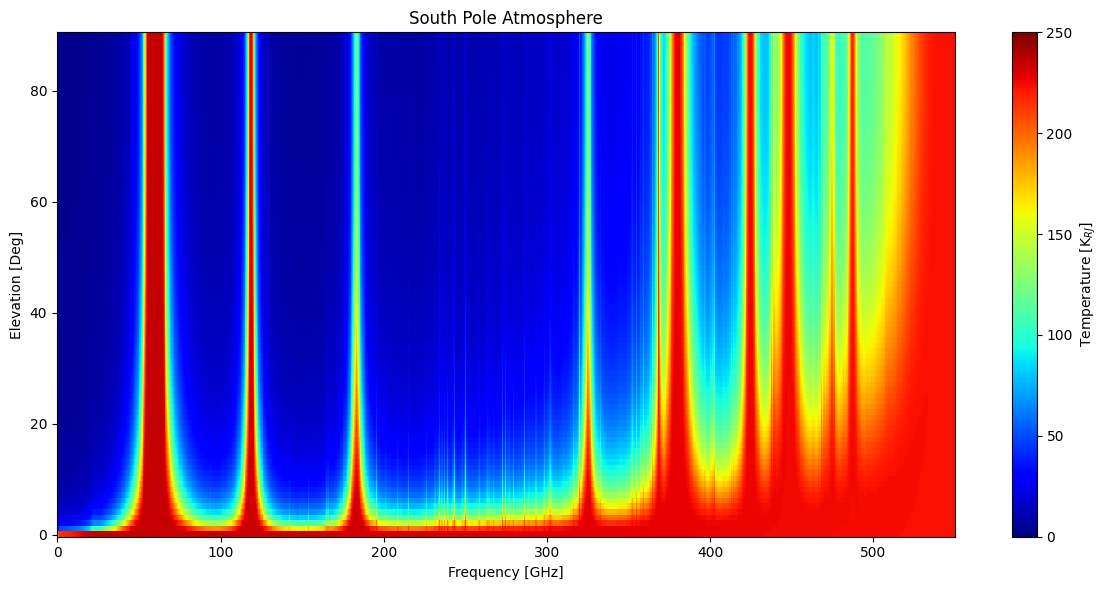

In [2]:
import am
import matplotlib.pyplot as plt
import numpy as np


def run_am(
    amc_path: Path,
    za_deg: float,
    h2o_scale: float = 1.0,
    fmin: float = 0.0,
    fmax: float = 550.0,
    df: float = 0.5,
):
    args = [
        f"{fmin}",
        "GHz",
        f"{fmax}",
        "GHz",
        f"{df}",
        "GHz",
        f"{za_deg}",
        "deg",
        f"{h2o_scale}",
    ]
    model = am.Model(str(amc_path), args)
    model.compute()
    return np.asarray(model.frequency), np.asarray(model.tb_rj)


elevations = np.linspace(0.1, 90.0, 91)
rows = []
freq = None

for elevation in elevations:
    zenith_angle = 90.0 - elevation
    f, tb_rj = run_am(AMC_FILE, za_deg=zenith_angle)
    if freq is None:
        freq = f
    rows.append(tb_rj)

temperature_grid = np.vstack(rows)

plt.figure(figsize=(12, 6))
mesh = plt.pcolormesh(
    freq, elevations, temperature_grid, shading="auto", cmap="jet", vmin=0, vmax=250
)
plt.xlabel("Frequency [GHz]")
plt.ylabel("Elevation [Deg]")
plt.title("South Pole Atmosphere")
cbar = plt.colorbar(mesh)
cbar.set_label(r"Temperature [$\text{K}_{RJ}]$")
plt.tight_layout()
plt.show()
